# WAVEGUISE applied to AWE data
WAVEGUISE is applied to an AWE swath over Crozet island in the south Indian ocean. Orbit 3175

In [13]:
import sys
sys.path.append("/home/r/Robert.Reichert/juwavelet")
import juwavelet.transform as transform
from juwavelet import utils
sys.path.append('../scripts')
import utils_2d as two

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import copy
from scipy import stats
import matplotlib.colors as mcolors
"""
import os

from matplotlib.colors import BoundaryNorm


from numpy.linalg import norm
from scipy.stats import circmean
"""
plt.style.use("../latex_default.mplstyle")

In [2]:
data_path = '../data/awe_l3c_q20_2024165T2120_03175_v01.nc'
ds = xr.open_dataset(data_path)

Text(0.5, 1.0, 'Orbit 03175')

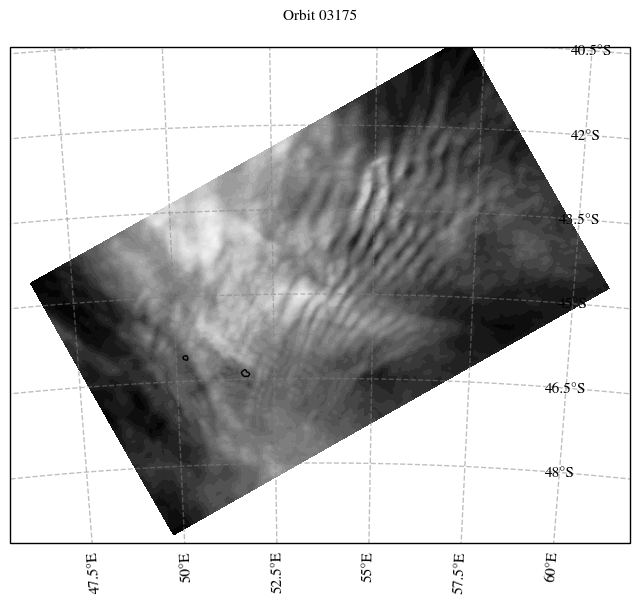

In [3]:
lon = ds['Longitude'].isel(time=0,x_along_track=slice(3000,3500),y_cross_track=slice(60,350))
lat = ds['Latitude'].isel(time=0,x_along_track=slice(3000,3500),y_cross_track=slice(60,350))
z   = ds['Radiance'].isel(time=0,x_along_track=slice(3000,3500),y_cross_track=slice(60,350))

lonW, lonE = lon.min(), lon.max()
latN, latS = lat.max(), lat.min()
clon, clat = (lonW+lonE)/2, (latN+latS)/2
projStr = ccrs.Stereographic(central_longitude=clon.values, central_latitude=clat.values)

# Define figure size
fig_width = 8
fig_height = 8

# Create the 3D plot
letterbox = {"boxstyle": "circle","lw": 0.67,"facecolor": "white","edgecolor": "black"}
Titel='Orbit 03175'

fig=plt.figure(figsize=(fig_width,fig_height))
ax = fig.add_subplot(projection=projStr)

ax.set_extent([lonW, lonE, latS, latN], ccrs.PlateCarree())
ax.coastlines()
gridlines = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gridlines.right_labels = True  # Hide labels on the right side
gridlines.left_labels = True  # Hide labels on the right side
gridlines.top_labels = False    # Hide labels on the top
gridlines.bottom_labels = True    # Hide labels on the top
    
BI_lev = np.linspace(10,40,31)
contour = ax.contourf(lon,lat,z,cmap='Greys_r',transform=ccrs.PlateCarree(),zorder=1,levels=BI_lev,extend='both')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(Titel,pad=20)

#plt.savefig('./AWE_plots/Crozet_03175.png', dpi=120, facecolor="w", edgecolor="w", bbox_inches="tight")

In [4]:
orig =ds["Radiance"].isel(time=0,x_along_track=slice(3000,3500),y_cross_track=slice(60,350))
orig-=orig.mean()
BI_high, BI_low = two.BG_removal(orig.values,max_order=1)
dx, dy = 2000, 2000
nx, ny = orig['x_along_track'].size, orig['y_cross_track'].size
y = np.linspace(0,(ny-1)*dy,ny)*1e-3
x = np.linspace(0,(nx-1)*dx,nx)*1e-3
print(nx, ny)

nmask  = orig.shape
ntap   = int(0.1*np.min(nmask))
signal = utils.smooth_edges(BI_high, ntap, window='tukey')

500 290


In [5]:
s0 = 2 * dx
dj = 1 / 8
js=int(1/dj*np.log2(min([nx,ny])/2*dx/s0))
jt = 21
print(js, jt)

result = transform.decompose2d(signal,dx,dy,s0,dj,js,jt,aspect=1,
                               nxpad=None,nypad=None,opts={'param': 2*np.pi},
                               mode="scaled",dtype=np.complex128)

print(result["period"][0],result["period"][-1])

49 21
4000.0 256000.0


In [10]:
cwt_copy   = copy.deepcopy(result)
WPS        = np.abs(cwt_copy['decomposition'])**2
median_WPS = np.median(WPS,axis=(1,2,3))
sMAD_WPS   = 1.4826*stats.median_abs_deviation(WPS,axis=(1,2,3))
WPS_scaled = (WPS-median_WPS[:,np.newaxis,np.newaxis,np.newaxis])/sMAD_WPS[:,np.newaxis,np.newaxis,np.newaxis]
mask       = WPS_scaled < 10
cwt_copy['decomposition'][mask]=0

In [11]:
wavy_stuff  = transform.reconstruct2d(cwt_copy)
noisy_stuff = signal - wavy_stuff 

<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\s'
/scratch-local/slurm-job-tmp-12238122/ipykernel_1798/4024040407.py:19: SyntaxWarning: invalid escape sequence '\s'
  ax.text(0.12,0.95, f"$\sigma_{{noise}} = {np.std(noisy_stuff):.2f}$", verticalalignment='center', horizontalalignment='center', weight = 'bold', bbox=titlebox, transform=ax.transAxes)


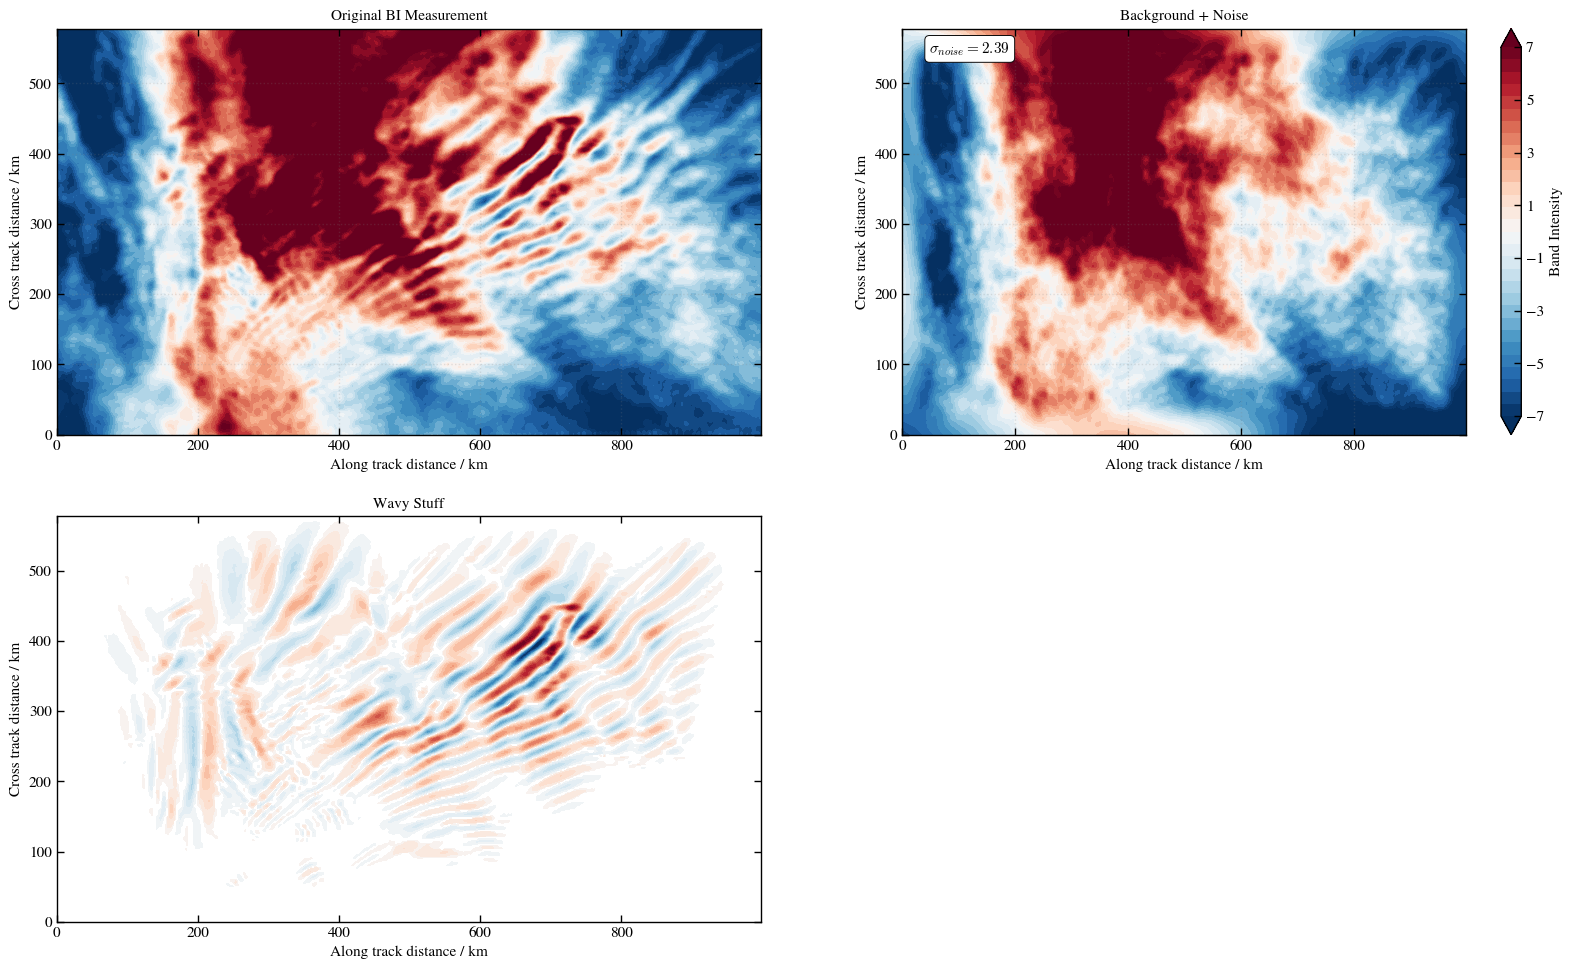

In [14]:
titlebox = {"boxstyle": "round", "lw": 0.67, "facecolor": "white", "edgecolor": "black"}

rad_lev   = np.linspace(-7,7,31)
lev_ticks = [-7,-5,-3,-1,1,3,5,7]

fig=plt.figure(figsize=(nx/25,ny/25))
ax=fig.add_subplot(221)
ax.contourf(x,y,orig,levels=rad_lev,extend="both",cmap="RdBu_r")
ax.set_title('Original BI Measurement')
ax.set_xlabel("Along track distance / km")
ax.set_ylabel("Cross track distance / km")

ax=fig.add_subplot(222)
plot_BG = ax.contourf(x,y,BI_low+noisy_stuff,levels=rad_lev,extend="both",cmap="RdBu_r")
ax.set_title('Background + Noise')
ax.set_xlabel("Along track distance / km")
ax.set_ylabel("Cross track distance / km")
cbar = fig.colorbar(plot_BG,label="Band Intensity",ticks=lev_ticks)
ax.text(0.12,0.95, f"$\sigma_{{noise}} = {np.std(noisy_stuff):.2f}$", verticalalignment='center', horizontalalignment='center', weight = 'bold', bbox=titlebox, transform=ax.transAxes)

ax=fig.add_subplot(223)
masked = np.ma.masked_inside(wavy_stuff, -0.2, 0.2)  
norm = mcolors.TwoSlopeNorm(vmin=rad_lev[0], vcenter=0.0, vmax=rad_lev[-1])
ax.contourf(x,y,masked,levels=rad_lev,cmap="RdBu_r",norm=norm,extend='both')
ax.set_title('Wavy Stuff')
ax.set_xlabel("Along track distance / km")
ax.set_ylabel("Cross track distance / km")
ax.grid(which='both')

#plt.savefig('./AWE_plots/AWE_preparation_03175.png', dpi=120, facecolor="w", edgecolor="w", bbox_inches="tight")